AI adoption is surging globally. Yet Indonesia a nation of 270 million, with growing internet penetration (72.8%), a rising HDI (0.728) and a functioning regulatory environment scores only **9/100** on the Tortois AI Readiness Index, ranking **#39 of 80 countries**.

Penggunaan AI meningkat secara drastis di seluruh dunia dalam 1 dekade terakhir. Indonesia sebagai negara dengan populasi 270 juta jiwa, tingkat penetrasi internet yang terus meningkat (72,8%), dan Indeks Pembangunan Manusia (IPM) yang terus naik (0,728) hanya memperoleh skor **9/100** pada Indeks Kesiapan AI Tortois, menempati peringkat **ke-39 dari 80 negara**.

Pada analisis ini, akan dikupas bahwa masalah yang dihadapi dari kondisi Indonesia saat ini bukan dibatasi oleh kapasitas namun *prioritas*.

Datasets:
- `final_global_country_ai_dataset.csv` Oxford Insights, Tortois, and United Nation aggregated AI Readiness, 80 countries
- `trend_country_year_2020_2024.csv` — Internet & GDP trends 2020–2024
- `fitped_dataset1.csv` — FITPED AI education survey, n=1,205 including Indonesian students

### Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from scipy import stats

In [ ]:
IDN   = '#E24B4A'
SING  = '#378ADD'
BRAZ  = '#1D9E75'
MUTED = '#888780'
AMBER = '#BA7517'
DARK  = '#2C2C2A'
HIGH  = '#4A90D9'
LOW   = '#C0BDB7'
INDIA = '#E8A838'

In [ ]:
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#FAFAF8',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linewidth'   : 0.5,
    'font.family'      : 'sans-serif',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'normal',
    'axes.labelsize'   : 11,
    'axes.titlepad'    : 14,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

### Import Dataset

In [ ]:
df = "https://drive.google.com/uc?id=1XbMG2fAOWLSwfuQQqb6w0IIruWDk6RyI"
df_trend = "https://drive.google.com/uc?id=1Z3x2Q5CSSvcfjIQaehZJ7jEGO7TEQFTX"
df_fp = "https://drive.google.com/uc?id=1BIy4219xU8GKhmgZzk1WQ04QiEBa35oy"

In [ ]:
df      = pd.read_csv(df)
df_trend= pd.read_csv(df_trend)
df_fp   = pd.read_csv(df_fp)

In [ ]:
df.head()

,country,ai_overall_score,ai_talent,ai_infrastructure,ai_operating_environment,ai_research,ai_development,ai_government_strategy,ai_commercial,ai_scale,...,expected_years_of_schooling,mean_years_of_schooling,internet_usage_pct,gdp_per_capita,rank_ai_overall,rank_hdi,rank_internet,rank_gdp_per_capita,highlight_group,is_top10_ai
0,United States,100,100,100,96,100,100,83,100,100,...,15.9,13.9,94.693802,84534.040784,1.0,15.0,21.0,7.0,United States,True
1,China,54,26,66,70,54,69,66,48,57,...,15.5,8.0,92.000000,13303.148154,2.0,54.0,32.0,47.0,China,True
2,Singapore,32,30,50,55,25,21,59,27,16,...,16.7,12.0,94.377572,90674.066633,3.0,11.0,22.0,4.0,Singapore,True
3,United Kingdom,30,32,27,90,23,12,65,25,24,...,17.8,13.5,95.472099,53246.367615,4.0,11.0,18.0,17.0,Other Countries,True
4,France,28,25,31,70,18,31,59,19,23,...,16.1,11.8,88.653816,46103.084086,5.0,23.0,42.0,21.0,Other Countries,True


In [ ]:
df_fp.head()

,Construct,Item,Count (Valid Responses),N/A Count,Mean,Std Dev,Skewness,Std Error of Skewness,Kurtosis,Std Error of Kurtosis
0,AI Literacy,L1,1205,0,4.559,0.727,-2.250,0.071,6.702,0.141
1,AI Literacy,L2,1205,0,4.529,0.718,-2.005,0.071,5.700,0.141
2,AI Literacy,L3,1205,0,3.954,1.018,-0.853,0.071,0.216,0.141
3,AI Literacy,L4,1205,0,3.230,1.361,-0.177,0.071,-1.219,0.141
4,AI Literacy,L5,1205,0,3.684,1.093,-0.526,0.071,-0.485,0.141


In [ ]:
df_trend.head()

,country,year,internet_usage_pct,gdp_per_capita,is_asean,is_focus_country,is_indonesia
0,Afghanistan,2020,17.048500,510.787063,False,False,False
1,Afghanistan,2021,16.514299,356.496214,False,False,False
2,Afghanistan,2022,15.866300,357.261153,False,False,False
3,Afghanistan,2023,15.928400,413.757895,False,False,False
4,Africa Eastern and Southern,2020,23.500000,1351.591669,False,False,False


In [ ]:
print(f"Global dataset : {df.shape[0]} countries × {df.shape[1]} features")
print(f"Trend dataset  : {df_trend.shape[0]} rows, {df_trend['country'].nunique()} countries")
print(f"FITPED dataset : {df_fp.shape[0]} items across {df_fp['Construct'].nunique()} constructs\n")

Global dataset : 80 countries × 22 features
Trend dataset  : 1062 rows, 220 countries
FITPED dataset : 50 items across 10 constructs



### Data Transformation

Analisis ini akan membandingkan Indonesia dengan Singapore dan Brazil, dua negara acuan yang dipilih karena masing-masing menjawab pertanyaan yang berbeda. Dua negara ini dipilih untuk menampilkan potensi dan bukti kemampuan perkembangan AI di Indonesia.

- Singapore memperlihatkan seperti apa prioritas strategi AI yang optimal dapat diwujudkan di kawasan ASEAN. Negara yang berdekatan secara geografis dan memiliki skor AI Operating Environment yang sama (55) dengan Indonesia. Singapura menunjukkan apa yang dihasilkan oleh investasi ekosistem yang terencana.

- Brazil memperlihatkan bahwa negara dengan tantangan kompleksitas yang setara  dapat meraih skor lebih tinggi 12  oleh dua faktor yang belum dimanfaatkan oleh Indonesia, Goverment Stategy (Brasil 36, Indonesia 19) dan Talent (Brasil 12, Indonesia 8). Brasil membuktikan bahwa batas kemampuannya lebih tinggi bukan karena kemudahan dan simplifikasi tantangan namun langkah-langkah pembangunan yang terencana.

In [ ]:
idn  = df[df['country'] == 'Indonesia'].iloc[0]
sing = df[df['country'] == 'Singapore'].iloc[0]
braz = df[df['country'] == 'Brazil'].iloc[0]
india = df[df['country'] == 'India'].iloc[0]

In [ ]:
for label, row in [('Indonesia', idn), ('Brazil', braz), ('Singapore', sing)]:
    print(f"  {label:<12} | Score {int(row['ai_overall_score']):>3}/100 "
          f"| Rank #{int(row['rank_ai_overall']):<3} "
          f"| HDI {row['hdi']:.3f} "
          f"| Internet {row['internet_usage_pct']:.1f}% "
          f"| GDP ${row['gdp_per_capita']:,.0f}")

  Indonesia    | Score   9/100 | Rank #39  | HDI 0.728 | Internet 72.8% | GDP $4,925
  Brazil       | Score  12/100 | Rank #27  | HDI 0.786 | Internet 84.5% | GDP $10,311
  Singapore    | Score  32/100 | Rank #3   | HDI 0.946 | Internet 94.4% | GDP $90,674


In [ ]:
df.describe()[['ai_overall_score','hdi','internet_usage_pct','gdp_per_capita']].round(2)

,ai_overall_score,hdi,internet_usage_pct,gdp_per_capita
count,80.00,80.00,75.00,75.00
mean,13.11,0.84,84.29,30801.63
std,12.95,0.12,17.34,30352.48
min,2.00,0.50,21.94,999.65
25%,6.75,0.78,81.72,6170.40
50%,9.00,0.87,90.44,23292.33
75%,16.00,0.92,95.09,49739.34
max,100.00,0.97,100.00,137781.68


### Global AI Landscape

In [ ]:
highlight = ['United States','China','Singapore','United Kingdom','France',
             'South Korea','Germany','India','Japan','Saudi Arabia',
             'Brazil','Malaysia','Thailand','Indonesia','Vietnam','Philippines']

In [ ]:
df_sel = (df[df['country'].isin(highlight)]
            .sort_values('ai_overall_score', ascending=True))

In [ ]:
def clr(c):
    return IDN if c=='Indonesia' else SING if c=='Singapore' else INDIA if c=='India' else BRAZ if c=='Brazil' else MUTED

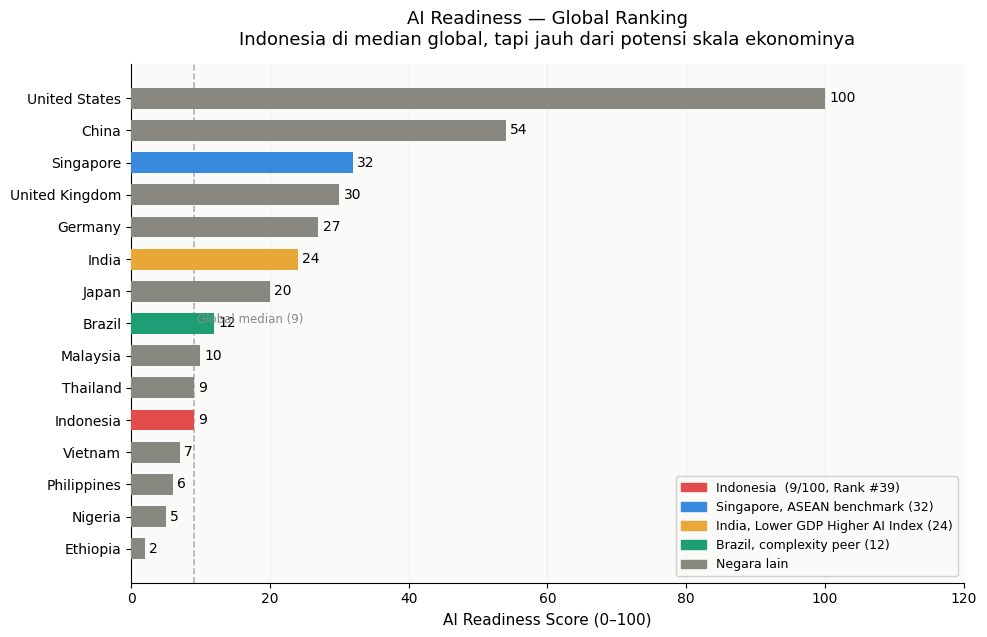

Indonesia rank #39 dari 80 negara | Skor 9/100


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(df_sel['country'], df_sel['ai_overall_score'],
               color=[clr(c) for c in df_sel['country']], height=0.65, zorder=3)

for bar, val in zip(bars, df_sel['ai_overall_score']):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', ha='left', fontsize=10)

# Global median line
gmed = df['ai_overall_score'].median()
ax.axvline(gmed, color=DARK, lw=1.2, ls='--', alpha=0.35)
ax.text(gmed + 0.5, 0.5, f'Global median ({gmed:.0f})',
        transform=ax.get_xaxis_transform(), fontsize=8.5, color='#888')

ax.set_xlim(0, 120)
ax.set_xlabel('AI Readiness Score (0–100)')
ax.set_title('AI Readiness — Global Ranking\n'
             'Indonesia di median global, tapi jauh dari potensi skala ekonominya', pad=14)
ax.grid(axis='y', alpha=0)

legend_el = [
    mpatches.Patch(color=IDN,   label='Indonesia  (9/100, Rank #39)'),
    mpatches.Patch(color=SING,  label='Singapore, ASEAN benchmark (32)'),
    mpatches.Patch(color=INDIA, label='India, Lower GDP Higher AI Index (24)'),
    mpatches.Patch(color=BRAZ,  label='Brazil, complexity peer (12)'),
    mpatches.Patch(color=MUTED, label='Negara lain'),
]
ax.legend(handles=legend_el, fontsize=9, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('beat1_global_rank.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Indonesia rank #{int(idn['rank_ai_overall'])} dari {len(df)} negara | Skor {int(idn['ai_overall_score'])}/100")

Dari ~80 negara, Indonesia mendapat nilai 9/100.
- **US memimpin dengan skor 100**; China dnegan skor 54; Singapore (ASEAN) dengan skor 32
- **Brazil (score 12)** dengan kompleksitas yang sama telah mengalahkan Indonesia
- Indonesia berada di peringkat pertengahan (median global)


### Asean AI Landscape

In [ ]:
asean_c = ['Singapore','Malaysia','Thailand','Indonesia','Vietnam','Philippines']
df_asean = df[df['country'].isin(asean_c)].copy()
df_asean = df_asean.set_index('country').loc[asean_c].reset_index()

In [ ]:
sub_dims = ['ai_talent','ai_research','ai_commercial','ai_development',
            'ai_infrastructure','ai_government_strategy']
sub_labels = ['Talent','Research','Commercial','Development',
              'Infrastructure','Gov. Strategy']

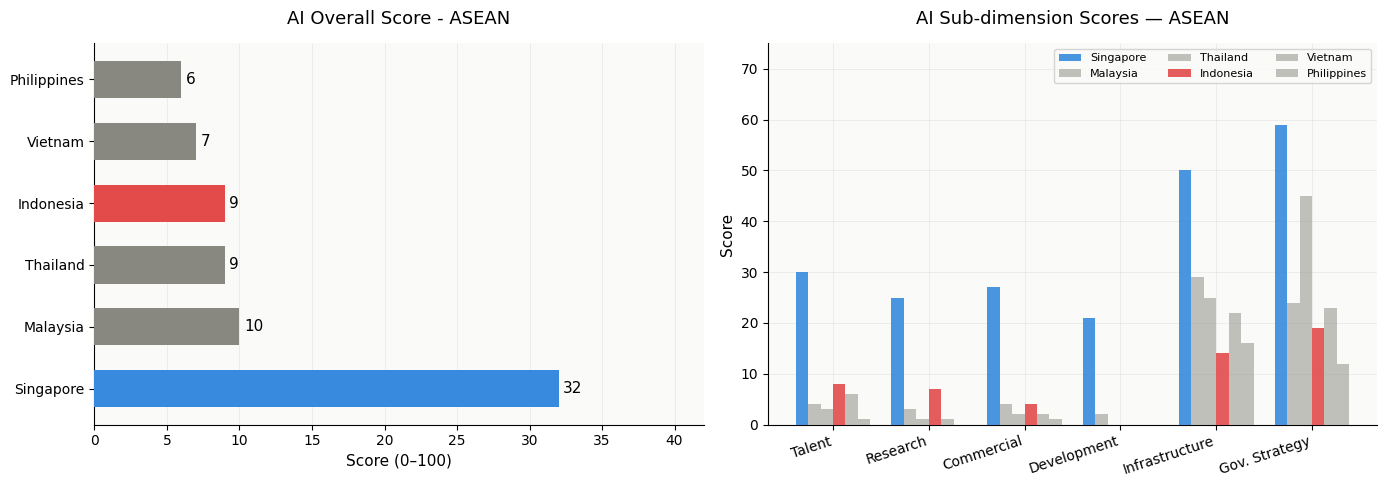

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall score
colors_a = [IDN if c=='Indonesia' else SING if c=='Singapore' else MUTED
            for c in df_asean['country']]
bars = axes[0].barh(df_asean['country'], df_asean['ai_overall_score'],
                    color=colors_a, height=0.6, zorder=3)
for bar, val in zip(bars, df_asean['ai_overall_score']):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 str(int(val)), va='center', ha='left', fontsize=11)
axes[0].set_title('AI Overall Score - ASEAN')
axes[0].set_xlabel('Score (0–100)')
axes[0].set_xlim(0, 42)
axes[0].grid(axis='y', alpha=0)

# Sub-dimension grouped bar
x = np.arange(len(sub_dims))
w = 0.13
for i, (row, c) in enumerate(zip(df_asean.itertuples(), asean_c)):
    vals = [getattr(row, d) for d in sub_dims]
    clr = IDN if c=='Indonesia' else SING if c=='Singapore' else MUTED
    axes[1].bar(x + i*w - 2.5*w, vals, w, label=c, color=clr,
                alpha=0.9 if c in ['Indonesia','Singapore'] else 0.5, zorder=3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(sub_labels, rotation=18, ha='right')
axes[1].set_title('AI Sub-dimension Scores — ASEAN')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8, ncol=3, loc='upper right')
axes[1].set_ylim(0, 75)

plt.tight_layout()
plt.savefig('fig_02_asean.png', dpi=150, bbox_inches='tight')
plt.show()

Indonesia is **4th of 6 ASEAN countries** in the dataset. Despite being the largest ASEAN economy by population (270M) and 2nd largest by nominal GDP, its AI score (9) is barely ahead of Vietnam (7) and Philippines (6), and far behind Singapore (32).

### Is Infrastructure The Real Problem?

In [ ]:
annotate_map = {
    'India'      : (INDIA,     'India\nGDP $2.7k\u2192 AI 24',  (8, -12)),
    'Qatar'      : ('#9B59B6', 'Qatar\nGDP $76k\u2192 AI 8',  (-75, 5)),
    'Iceland'    : ('#7F8C8D', 'Iceland\nHDI 0.97\u2192 AI 10', (6, 3)),
    'Bahrain'    : ('#E67E22', 'Bahrain\n100% inet\u2192 AI 7',  (6, 3)),
    'Jordan'     : ('#16A085', 'Jordan\n95% inet\u2192 AI 7',    (6, -12)),
    'New Zealand': ('#8E44AD', 'New Zeal.\nHDI 0.94\u2192 AI 9',(-80, 5)),
    'Indonesia'  : (IDN,       'Indonesia',                        (6, 3)),
    'Singapore'  : (SING,      'Singapore',                        (6, 3)),
}

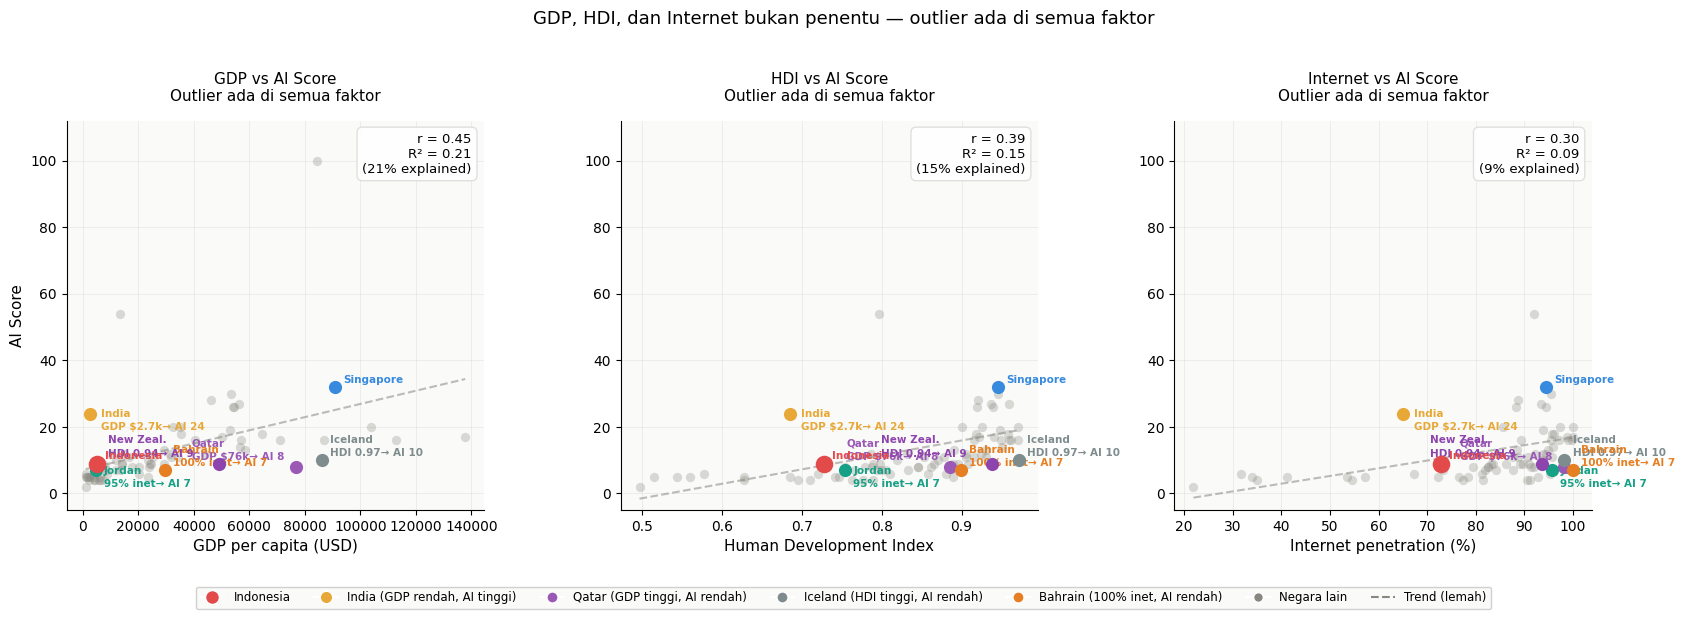

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

scatter_cfg = [
    ('gdp_per_capita',     'GDP per capita (USD)', 'GDP'),
    ('hdi',                'Human Development Index', 'HDI'),
    ('internet_usage_pct', 'Internet penetration (%)', 'Internet'),
]

for ax, (col, xlabel, title) in zip(axes, scatter_cfg):
    sub = df[['country','ai_overall_score', col]].dropna()
    x, y = sub[col], sub['ai_overall_score']
    sl, ic, rv, *_ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 200)

    ax.scatter(x, y, color=MUTED, alpha=0.3, s=45, zorder=2, linewidths=0)
    ax.plot(xl, sl*xl + ic, color=MUTED, lw=1.5, ls='--', alpha=0.55, zorder=3)

    for country, (color, label, offset) in annotate_map.items():
        row = sub[sub['country'] == country]
        if len(row) == 0: continue
        xv, yv = float(row[col].values[0]), float(row['ai_overall_score'].values[0])
        sz = 160 if country == 'Indonesia' else 90
        ax.scatter(xv, yv, color=color, s=sz, zorder=5, linewidths=0)
        ax.annotate(label, (xv, yv), xytext=offset, textcoords='offset points',
                    fontsize=7.5, color=color, fontweight='bold', linespacing=1.4)

    r2 = rv**2
    ax.text(0.97, 0.97, f'r = {rv:.2f}\nR\u00b2 = {r2:.2f}\n({r2*100:.0f}% explained)',
            transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='#ddd'))

    ax.set_xlabel(xlabel)
    ax.set_ylabel('AI Score' if ax == axes[0] else '')
    ax.set_title(f'{title} vs AI Score\nOutlier ada di semua faktor', fontsize=11)
    ax.set_ylim(-5, 112)

fig.suptitle('GDP, HDI, dan Internet bukan penentu — outlier ada di semua faktor',
             fontsize=13, y=1.02)

legend_el2 = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=IDN,       markersize=10, label='Indonesia'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=INDIA,     markersize=9,  label='India (GDP rendah, AI tinggi)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#9B59B6', markersize=8,  label='Qatar (GDP tinggi, AI rendah)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#7F8C8D', markersize=8,  label='Iceland (HDI tinggi, AI rendah)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E67E22', markersize=8,  label='Bahrain (100% inet, AI rendah)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=MUTED,     markersize=7,  label='Negara lain'),
    Line2D([0],[0], color=MUTED, lw=1.5, ls='--', label='Trend (lemah)'),
]
fig.legend(handles=legend_el2, loc='lower center', ncol=7, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.08), framealpha=0.9)

plt.tight_layout()
plt.savefig('beat2_scatter_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


Outliernya ada di mana-mana

- **Qatar**: GDP \$76k/orang, internet 100%, AI score **8**
- **Iceland**: HDI 0.972 (tertinggi di dataset), AI score **10**  
- **India**: GDP hanya \$2.7k/orang, AI score **24**

Artinya: uang, pendidikan, dan koneksi internet bukan kunci utama.

### Driver of AI Readiness

In [ ]:
peer = df[(df['gdp_per_capita'] >= 1000) & (df['gdp_per_capita'] <= 12000)].dropna(subset=['gdp_per_capita']).copy()

In [ ]:
peer

,country,ai_overall_score,ai_talent,ai_infrastructure,ai_operating_environment,ai_research,ai_development,ai_government_strategy,ai_commercial,ai_scale,...,expected_years_of_schooling,mean_years_of_schooling,internet_usage_pct,gdp_per_capita,rank_ai_overall,rank_hdi,rank_internet,rank_gdp_per_capita,highlight_group,is_top10_ai
9,India,24,42,15,90,10,13,55,14,24,...,13.0,6.9,64.943497,2694.737809,10.0,72.0,67.0,67.0,India,True
26,Brazil,12,12,22,67,3,5,36,7,11,...,15.8,8.4,84.463472,10310.548878,27.0,59.0,50.0,50.0,Other Countries,False
35,Malaysia,10,4,29,68,3,2,24,4,8,...,12.7,11.1,98.020606,11874.427368,36.0,49.0,9.0,49.0,Malaysia,False
39,Thailand,9,3,25,48,1,0,45,2,8,...,15.4,9.0,90.867188,7346.620221,39.0,53.0,36.0,54.0,Thailand,False
45,Indonesia,9,8,14,55,7,0,19,4,8,...,13.3,8.7,72.780755,4925.430488,39.0,68.0,64.0,60.0,Indonesia,False
47,Colombia,8,5,19,54,0,1,40,1,7,...,14.3,9.0,79.345433,7919.208868,47.0,58.0,59.0,53.0,Other Countries,False
51,Ukraine,8,5,17,62,1,1,30,2,7,...,13.3,11.1,82.474899,5389.473145,47.0,60.0,54.0,59.0,Other Countries,False
54,Vietnam,7,6,22,44,1,0,23,2,6,...,15.5,9.0,84.150000,4717.290287,54.0,62.0,51.0,61.0,Vietnam,False
55,Mauritius,7,1,15,36,1,0,24,8,5,...,14.2,10.1,73.307935,11990.779894,54.0,51.0,63.0,48.0,Other Countries,False
57,Peru,7,4,18,64,0,0,21,1,6,...,14.9,10.2,81.957060,8452.371671,54.0,55.0,56.0,52.0,Other Countries,False


/tmp/ipykernel_3603/1382611565.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  (float(row['ai_government_strategy']), float(row['ai_overall_score'])),


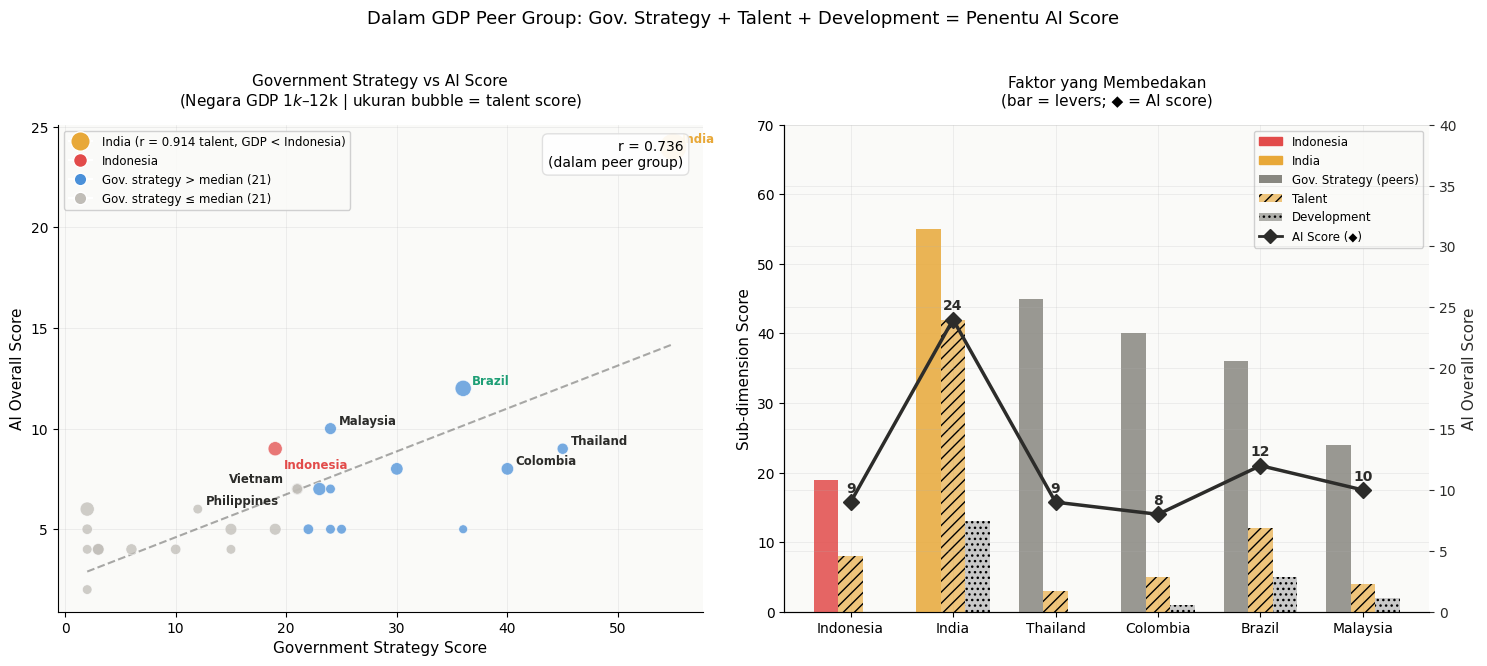

Korelasi dalam GDP peer group ($1k–$12k):
  Talent               r = 0.914  (p = 0.0000)
  Development          r = 0.883  (p = 0.0000)
  Gov. Strategy        r = 0.736  (p = 0.0000)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# gov_strategy vs AI score in peer group
# bubble size = talent score
peer_plot = peer.copy()

# gov_strategy > median peer group
gov_med = peer_plot['ai_government_strategy'].median()
dot_colors = [
    INDIA if row.country == 'India'
    else IDN if row.country == 'Indonesia'
    else HIGH if row.ai_government_strategy > gov_med
    else LOW
    for row in peer_plot.itertuples()
]

bubble_sizes = (peer_plot['ai_talent'] * 8 + 40).clip(40, 500)

sc = axes[0].scatter(peer_plot['ai_government_strategy'], peer_plot['ai_overall_score'],
                     s=bubble_sizes, c=dot_colors, alpha=0.75, zorder=3, linewidths=0.5,
                     edgecolors='white')

# Trend line dalam peer group
sl_p, ic_p, rv_p, *_ = stats.linregress(peer_plot['ai_government_strategy'],
                                          peer_plot['ai_overall_score'])
xl_p = np.linspace(peer_plot['ai_government_strategy'].min(),
                   peer_plot['ai_government_strategy'].max(), 200)
axes[0].plot(xl_p, sl_p*xl_p + ic_p, color=DARK, lw=1.5, ls='--', alpha=0.4, zorder=2)

# negara highlighted
label_these = {
    'India'      : (INDIA, ( 6,  3)),
    'Indonesia'  : (IDN,   ( 6, -14)),
    'Thailand'   : (DARK,  ( 6,  3)),
    'Colombia'   : (DARK,  ( 6,  3)),
    'Vietnam'    : (DARK,  (-65, 5)),
    'Philippines': (DARK,  ( 6,  3)),
    'Brazil'     : (BRAZ,  ( 6,  3)),
    'Malaysia'   : (DARK,  ( 6,  3)),
}
for country, (color, offset) in label_these.items():
    row = peer_plot[peer_plot['country'] == country]
    if len(row) == 0: continue
    axes[0].annotate(country,
                     (float(row['ai_government_strategy']), float(row['ai_overall_score'])),
                     xytext=offset, textcoords='offset points',
                     fontsize=8.5, color=color, fontweight='bold')

axes[0].text(0.97, 0.97, f'r = {rv_p:.3f}\n(dalam peer group)',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='#ddd'))

axes[0].set_xlabel('Government Strategy Score')
axes[0].set_ylabel('AI Overall Score')
axes[0].set_title('Government Strategy vs AI Score\n(Negara GDP $1k–$12k | ukuran bubble = talent score)',
                  fontsize=11)

legend_bubble = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=INDIA, markersize=14,
           label='India (r = 0.914 talent, GDP < Indonesia)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=IDN,   markersize=10, label='Indonesia'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=HIGH,  markersize=9,
           label=f'Gov. strategy > median ({gov_med:.0f})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=LOW,   markersize=9,
           label=f'Gov. strategy ≤ median ({gov_med:.0f})'),
]
axes[0].legend(handles=legend_bubble, fontsize=8.5, loc='upper left', framealpha=0.9)

# Indonesia vs India vs target
compare_countries = ['Indonesia','India','Thailand','Colombia','Brazil','Malaysia']
compare_df = df[df['country'].isin(compare_countries)].set_index('country').loc[compare_countries]

levers = ['ai_government_strategy', 'ai_talent', 'ai_development']
lever_labels = ['Gov. Strategy', 'Talent', 'Development']

x = np.arange(len(compare_countries))
w = 0.24
bar_colors_lever = [MUTED, INDIA, '#B0B0B0']

for i, (lever, label, bc) in enumerate(zip(levers, lever_labels, bar_colors_lever)):
    vals  = [compare_df.loc[c, lever] for c in compare_countries]
    b_clr = [IDN if c=='Indonesia' else INDIA if c=='India' else MUTED
             for c in compare_countries]
    bars_r = axes[1].bar(x + (i - 1)*w, vals, w,
                         color=b_clr if lever == 'ai_government_strategy' else bc,
                         alpha=0.85 if i == 0 else 0.65,
                         label=label, zorder=3,
                         hatch='' if i==0 else ('///' if i==1 else '...'))

# AI score as line overlay
ax2_twin = axes[1].twinx()
ai_vals = [compare_df.loc[c, 'ai_overall_score'] for c in compare_countries]
ax2_twin.plot(x, ai_vals, color=DARK, lw=2.5, marker='D', markersize=8,
              zorder=5, label='AI Overall Score')
ax2_twin.set_ylabel('AI Overall Score', color=DARK)
ax2_twin.tick_params(axis='y', colors=DARK)
ax2_twin.set_ylim(0, 40)

for xi, val in zip(x, ai_vals):
    ax2_twin.text(xi, val + 0.8, str(int(val)), ha='center', fontsize=10,
                  fontweight='bold', color=DARK)

axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_countries, fontsize=10)
axes[1].set_ylabel('Sub-dimension Score')
axes[1].set_title('Faktor yang Membedakan\n'
                  '(bar = levers; ◆ = AI score)', fontsize=11)
axes[1].set_ylim(0, 70)

lever_legend = [
    mpatches.Patch(color=IDN,   label='Indonesia'),
    mpatches.Patch(color=INDIA, label='India'),
    mpatches.Patch(facecolor=MUTED, label='Gov. Strategy (peers)'),
    mpatches.Patch(facecolor=INDIA, hatch='///', alpha=0.65, label='Talent'),
    mpatches.Patch(facecolor=MUTED, hatch='...', alpha=0.65, label='Development'),
    Line2D([0],[0], color=DARK, lw=2, marker='D', markersize=7, label='AI Score (◆)'),
]
axes[1].legend(handles=lever_legend, fontsize=8.5, loc='upper right', framealpha=0.9)

plt.suptitle('Dalam GDP Peer Group: Gov. Strategy + Talent + Development = Penentu AI Score',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('beat3_peer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Korelasi dalam GDP peer group ($1k–$12k):")
for col, label in [('ai_talent','Talent'), ('ai_development','Development'),
                   ('ai_government_strategy','Gov. Strategy')]:
    r, p = stats.pearsonr(peer['ai_overall_score'], peer[col])
    print(f"  {label:<20} r = {r:.3f}  (p = {p:.4f})")

### Radar Chart

In [ ]:
AMBER_C = '#E8A838'
order = ['AI Literacy','AI Readiness','Relevance of AI','Social Goods',
         'Behavioural Intention','Career Motivation','Confidence',
         'Intrinsic Motivation','Satisfaction','AI Anxiety']
means = df_fp.groupby('Construct')['Mean'].mean().reindex(order)

In [ ]:
def fp_clr(c):
    if c == 'AI Literacy':           return SING
    if c == 'AI Anxiety':            return IDN
    if c in ('Confidence','Intrinsic Motivation','Satisfaction'): return AMBER_C
    if c == 'Behavioural Intention': return DARK
    return MUTED

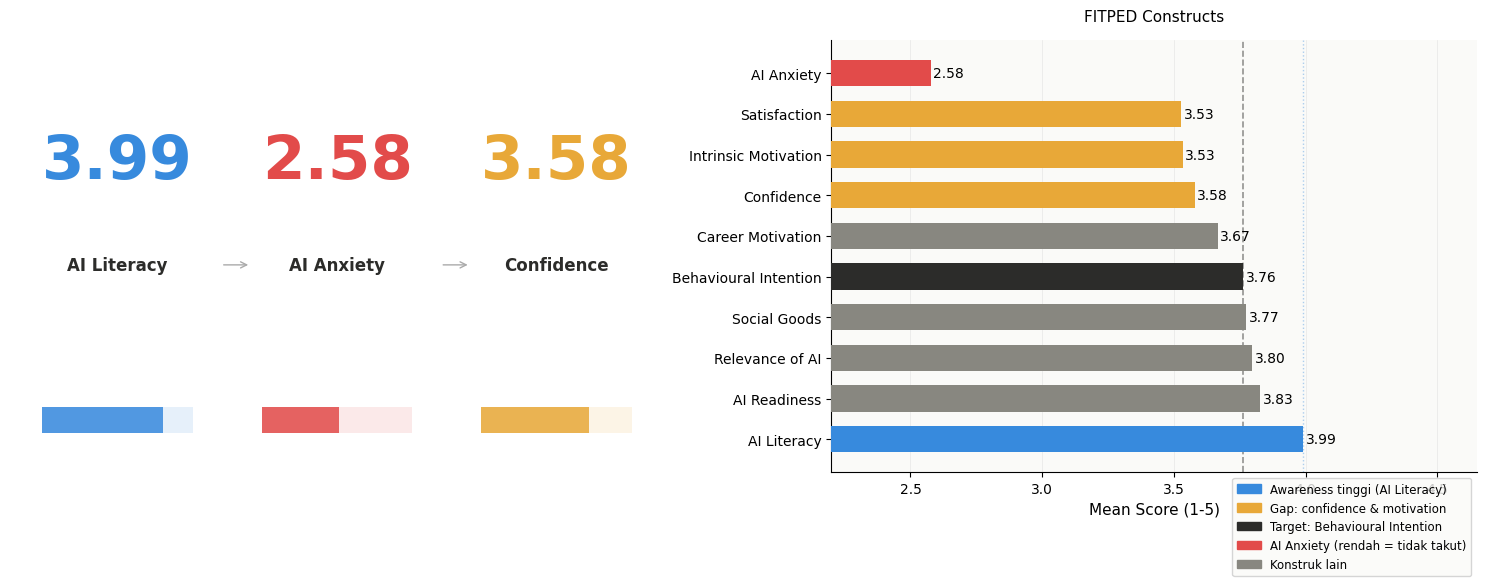

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# label_tahu    = 'TAHU tentang AI'
# label_takut   = 'TIDAK TAKUT AI\n(skor rendah = tidak cemas)'
# label_percaya = 'BELUM PERCAYA DIRI\npakai AI'

highlight = [
    ('AI Literacy', means['AI Literacy'],  SING),#    label_tahu),
    ('AI Anxiety',  means['AI Anxiety'],   IDN),#     label_takut),
    ('Confidence',  means['Confidence'],   AMBER_C)#, label_percaya),
]

ax = axes[0]
ax.axis('off')
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)

for i, (label, val, color) in enumerate(highlight):
    xc = i * 1.02 + 0.5
    ax.text(xc, 0.72, f'{val:.2f}', ha='center', va='center',
            fontsize=44, fontweight='bold', color=color)
    ax.text(xc, 0.48, label, ha='center', va='center',
            fontsize=12, fontweight='bold', color=DARK)
    # ax.text(xc, 0.28, desc, ha='center', va='center',
    #         fontsize=10, color='#666', linespacing=1.5)
    bar_len = val / 5 * 0.7
    ax.barh(0.12, bar_len, left=xc - 0.35, height=0.06, color=color, alpha=0.85)
    ax.barh(0.12, 0.7,     left=xc - 0.35, height=0.06, color=color, alpha=0.12)

ax.annotate('', xy=(1.12, 0.48), xytext=(0.98, 0.48),
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.))
#ax.text(1.25, 0.56, 'tapi...', ha='center', fontsize=9.5, color='#888', style='italic')
ax.annotate('', xy=(2.14, 0.48), xytext=(2.00, 0.48),
            arrowprops=dict(arrowstyle='->', color='#aaa', lw=1.))
#ax.text(2.27, 0.56, 'tapi...', ha='center', fontsize=9.5, color='#888', style='italic')
# ax.set_title('Tiga Angka Kunci — FITPED (n=1.205 siswa Indonesia)\n'
#              'Tahu dan tidak takut, tapi belum punya pengalaman aplikatif', fontsize=11)

# construct bar
bar_colors_fp = [fp_clr(c) for c in means.index]
bars_fp = axes[1].barh(means.index, means.values, color=bar_colors_fp, height=0.65, zorder=3)
for bar, val in zip(bars_fp, means.values):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', ha='left', fontsize=10)

axes[1].axvline(means['Behavioural Intention'], color=DARK, lw=1.2, ls='--', alpha=0.5,
                label=f'Behavioural Intention ({means["Behavioural Intention"]:.2f})')
axes[1].axvline(means['AI Literacy'], color=SING, lw=1.0, ls=':', alpha=0.4,
                label=f'AI Literacy ({means["AI Literacy"]:.2f})')
axes[1].set_xlim(2.2, 4.65)
axes[1].set_xlabel('Mean Score (1-5)')
axes[1].set_title('FITPED Constructs', fontsize=11)

leg_fp = [
    mpatches.Patch(color=SING,    label='Awareness tinggi (AI Literacy)'),
    mpatches.Patch(color=AMBER_C, label='Gap: confidence & motivation'),
    mpatches.Patch(color=DARK,    label='Target: Behavioural Intention'),
    mpatches.Patch(color=IDN,     label='AI Anxiety (rendah = tidak takut)'),
    mpatches.Patch(color=MUTED,   label='Konstruk lain'),
]
axes[1].legend(handles=leg_fp, fontsize=8.5, bbox_to_anchor=(1, 0))
axes[1].grid(axis='y', alpha=0)

plt.tight_layout()
plt.savefig('beat4_fitped.png', dpi=150, bbox_inches='tight')
plt.show()


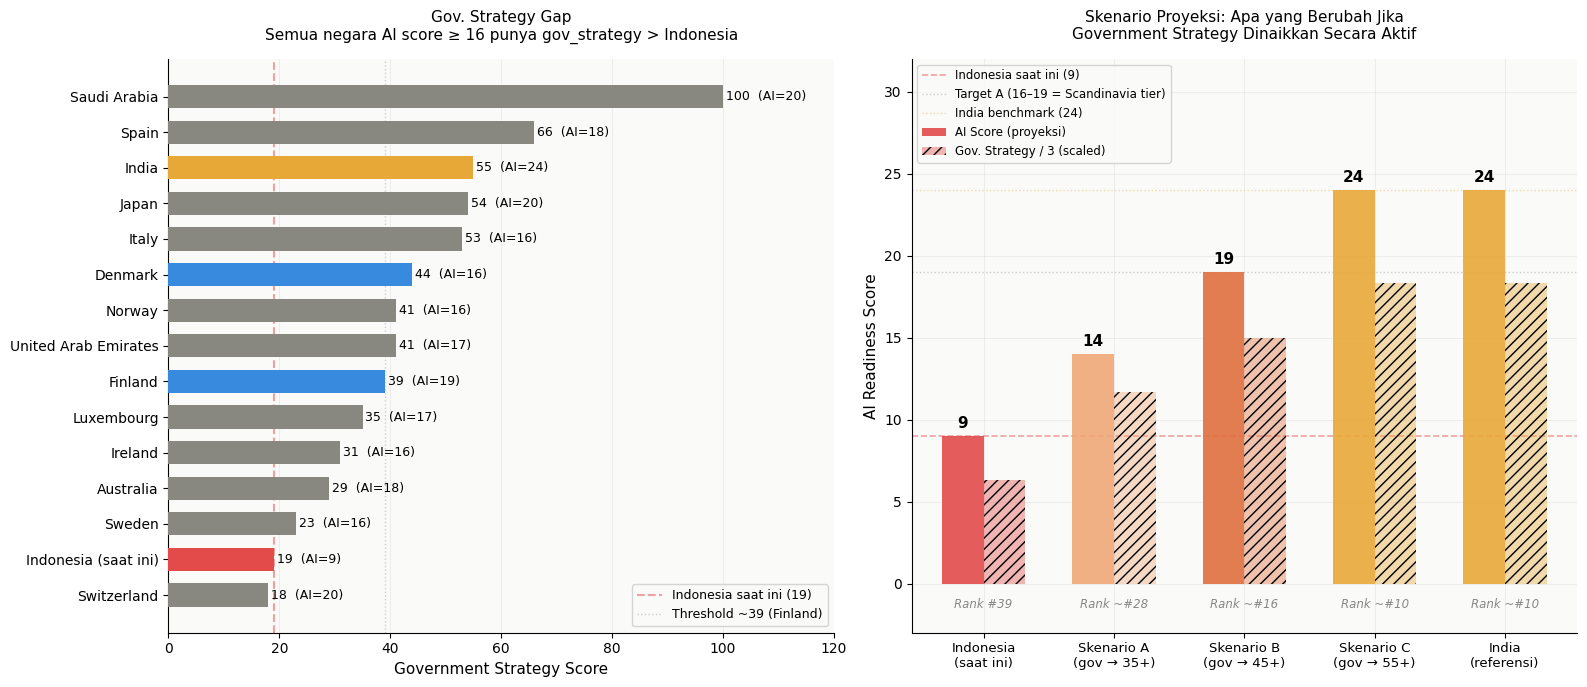


Gap summary:
  Indonesia gov_strategy    : 19
  Minimum target (Finlandia): 39
  India (GDP < Indonesia)   : 55

  Jika Indonesia naik ke ~45: proyeksi Rank ~#16 (level Finlandia/Scandinavia)


In [ ]:
# Target range countries
target = df[(df['ai_overall_score'] >= 16) & (df['ai_overall_score'] <= 25)].copy()
target = target.sort_values('ai_overall_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gap gov_strategy
t_show = target[['country','ai_overall_score','ai_government_strategy',
                 'ai_talent','ai_development','gdp_per_capita']].copy()
t_show = pd.concat([
    t_show,
    pd.DataFrame([{'country':'Indonesia (saat ini)',
                   'ai_overall_score': int(idn['ai_overall_score']),
                   'ai_government_strategy': int(idn['ai_government_strategy']),
                   'ai_talent': int(idn['ai_talent']),
                   'ai_development': int(idn['ai_development']),
                   'gdp_per_capita': idn['gdp_per_capita']}])
], ignore_index=True)

t_sorted = t_show.sort_values('ai_government_strategy', ascending=True)
colors_t = [IDN if 'Indonesia' in c else
            INDIA if c == 'India' else
            SING if c in ['Singapore','Denmark','Finland'] else MUTED
            for c in t_sorted['country']]

bars_t = axes[0].barh(t_sorted['country'], t_sorted['ai_government_strategy'],
                      color=colors_t, height=0.65, zorder=3)
for bar, row in zip(bars_t, t_sorted.itertuples()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{int(row.ai_government_strategy)}  (AI={int(row.ai_overall_score)})",
                 va='center', ha='left', fontsize=9)

axes[0].axvline(idn['ai_government_strategy'], color=IDN, lw=1.5, ls='--', alpha=0.5,
                label=f'Indonesia saat ini ({int(idn["ai_government_strategy"])})')
axes[0].axvline(39, color='#888', lw=1, ls=':', alpha=0.4, label='Threshold ~39 (Finland)')
axes[0].set_xlim(0, 120)
axes[0].set_xlabel('Government Strategy Score')
axes[0].set_title('Gov. Strategy Gap\nSemua negara AI score ≥ 16 punya gov_strategy > Indonesia',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0)

# Scenario projection
scenarios = [
    ('Indonesia\n(saat ini)',    9, 19,  8,  0, IDN),
    ('Skenario A\n(gov → 35+)', 14, 35, 15,  5, '#f0a878'),
    ('Skenario B\n(gov → 45+)', 19, 45, 25, 10, '#e07040'),
    ('Skenario C\n(gov → 55+)', 24, 55, 42, 13, INDIA),
    ('India\n(referensi)',       24, 55, 42, 13, INDIA),
]

label_s  = [s[0] for s in scenarios[:-1]] + ['India\n(referensi)']
scores_s = [s[1] for s in scenarios]
govs_s   = [s[2] for s in scenarios]
colors_s = [s[5] for s in scenarios]

x_s = np.arange(len(scenarios))
w_s = 0.32

b1 = axes[1].bar(x_s - w_s/2, scores_s, w_s, color=colors_s, alpha=0.9,
                 label='AI Score (proyeksi)', zorder=3)
b2 = axes[1].bar(x_s + w_s/2, [s[2]/3 for s in scenarios], w_s,
                 color=colors_s, alpha=0.4, hatch='///',
                 label='Gov. Strategy / 3 (scaled)', zorder=3)

for bar, sc in zip(b1, scores_s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(sc)), ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].axhline(9,  color=IDN,  lw=1.2, ls='--', alpha=0.5, label='Indonesia saat ini (9)')
axes[1].axhline(19, color='#888', lw=1, ls=':', alpha=0.4, label='Target A (16–19 = Scandinavia tier)')
axes[1].axhline(24, color=INDIA, lw=1, ls=':', alpha=0.4, label='India benchmark (24)')

# Rank annotation
rank_map = {9: '#39', 14: '~#28', 19: '~#16', 24: '~#10', 24: '~#10'}
for xi, sc, gov, nm in zip(x_s, scores_s, govs_s, [s[0] for s in scenarios]):
    rank = {9:'Rank #39', 14:'Rank ~#28', 19:'Rank ~#16', 24:'Rank ~#10', 24:'Rank ~#10'}
    axes[1].text(xi, -1.5, rank.get(sc,''), ha='center', fontsize=8.5,
                 color='#888', style='italic')

axes[1].set_xticks(x_s)
axes[1].set_xticklabels(label_s, fontsize=9.5)
axes[1].set_ylim(-3, 32)
axes[1].set_ylabel('AI Readiness Score')
axes[1].set_title('Skenario Proyeksi: Apa yang Berubah Jika\n'
                  'Government Strategy Dinaikkan Secara Aktif', fontsize=11)
axes[1].legend(fontsize=8.5, loc='upper left')

# plt.suptitle('CTA: Naikkan gov_strategy (19 → 45+) = kunci masuk tier Jepang/Finlandia',
#              fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('beat5_cta.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGap summary:")
print(f"  Indonesia gov_strategy    : {int(idn['ai_government_strategy'])}")
print(f"  Minimum target (Finlandia): 39")
print(f"  India (GDP < Indonesia)   : {int(india['ai_government_strategy'])}")
print(f"\n  Jika Indonesia naik ke ~45: proyeksi Rank ~#16 (level Finlandia/Scandinavia)")